In [4]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

In [5]:
df_4o = pd.read_json("data/short-form-factuality/gpqa_results_gpt-4o_assistant.json")
df_4o_mini = pd.read_json("data/short-form-factuality/gpqa_results_gpt-4o-mini.json")

In [6]:
df_4o = df_4o.head(250)
df_4o_mini = df_4o_mini.head(250)

In [7]:
# Count the frequency of each grade letter
grade_distribution = df_4o['grade_letter'].value_counts()

# To see it as percentages
grade_distribution_percentage = df_4o['grade_letter'].value_counts(normalize=True) * 100

# To view the results
print(grade_distribution)
print(grade_distribution_percentage)

grade_letter
B    154
A     66
C     30
Name: count, dtype: int64
grade_letter
B    61.6
A    26.4
C    12.0
Name: proportion, dtype: float64


In [8]:
# Count the frequency of each grade letter
grade_distribution = df_4o_mini['grade_letter'].value_counts()

# To see it as percentages
grade_distribution_percentage = df_4o_mini['grade_letter'].value_counts(normalize=True) * 100

# To view the results
print(grade_distribution)
print(grade_distribution_percentage)

grade_letter
B    172
A     42
C     36
Name: count, dtype: int64
grade_letter
B    68.8
A    16.8
C    14.4
Name: proportion, dtype: float64


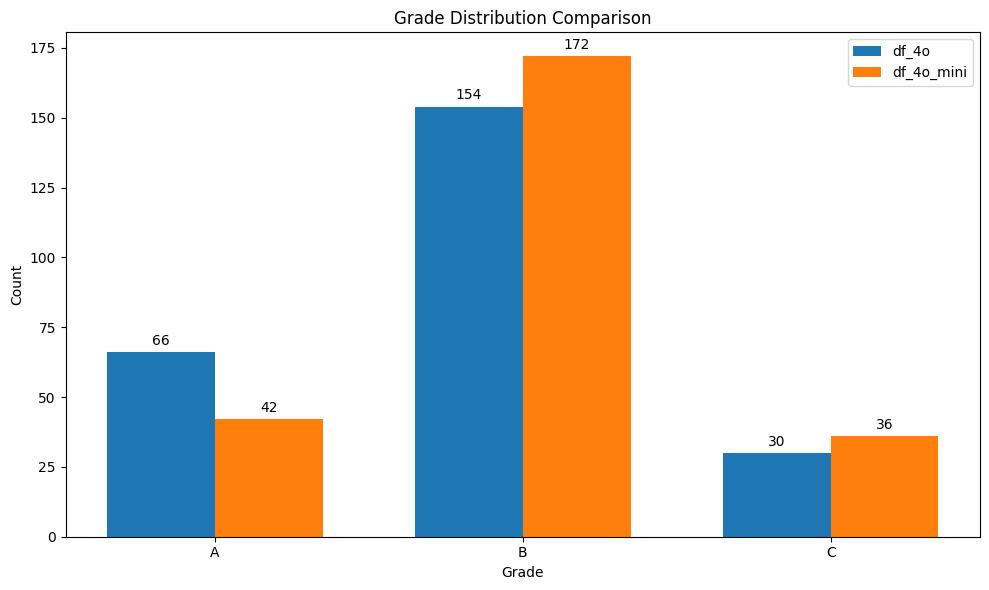

In [9]:
# Get value counts for both dataframes
counts_4o = df_4o['grade_letter'].value_counts()
counts_4o_mini = df_4o_mini['grade_letter'].value_counts()

# Make sure both have the same index (all grade letters)
all_grades = sorted(set(counts_4o.index) | set(counts_4o_mini.index))
counts_4o = counts_4o.reindex(all_grades, fill_value=0)
counts_4o_mini = counts_4o_mini.reindex(all_grades, fill_value=0)

# Sort in standard grade order if needed
standard_order = ['A', 'B', 'C', 'D', 'F']
# Filter to only include grades that exist in your data
standard_order = [grade for grade in standard_order if grade in all_grades]
counts_4o = counts_4o.reindex(standard_order)
counts_4o_mini = counts_4o_mini.reindex(standard_order)

# Set up the bar chart
x = np.arange(len(standard_order))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, counts_4o, width, label='df_4o')
rects2 = ax.bar(x + width/2, counts_4o_mini, width, label='df_4o_mini')

# Add labels and title
ax.set_title('Grade Distribution Comparison')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(standard_order)
ax.legend()

# Optional: Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [10]:
counts_4o

grade_letter
A     66
B    154
C     30
Name: count, dtype: int64

In [11]:
counts_4o["A"]

66

In [12]:
print(
    "GPT-4o:     ",
    "correct", f'{counts_4o["A"]/len(df_4o):0.3f},', 
    "not attempted", f'{counts_4o["C"]/len(df_4o):0.3f},', 
    "incorrect", f'{counts_4o["B"]/len(df_4o):0.3f},',
    "correct given attempted", f'{counts_4o["A"]/(counts_4o["A"]+counts_4o["B"]):0.3f},',
    "F-score", f'{(2*counts_4o["A"])/((2*counts_4o["A"])+(2*counts_4o["B"])+counts_4o["C"]):0.3f}'
)
print(
    "GPT-4o-mini:",
    "correct", f'{counts_4o_mini["A"]/len(df_4o_mini):0.3f},', 
    "not attempted", f'{counts_4o_mini["C"]/len(df_4o_mini):0.3f},', 
    "incorrect", f'{counts_4o_mini["B"]/len(df_4o_mini):0.3f},',
    "correct given attempted", f'{counts_4o_mini["A"]/(counts_4o_mini["A"]+counts_4o_mini["B"]):0.3f},',
    "F-score", f'{(2*counts_4o_mini["A"])/((2*counts_4o_mini["A"])+(2*counts_4o_mini["B"])+counts_4o_mini["C"]):0.3f}'
)

GPT-4o:      correct 0.264, not attempted 0.120, incorrect 0.616, correct given attempted 0.300, F-score 0.281
GPT-4o-mini: correct 0.168, not attempted 0.144, incorrect 0.688, correct given attempted 0.196, F-score 0.181


In [13]:
counts_4o_mini

grade_letter
A     42
B    172
C     36
Name: count, dtype: int64

In [14]:
grade_distribution["B"]

172

In [15]:
def load_and_prepare_data(dataset_size):
    df = pd.read_json("data/short-form-factuality/simpleqa_results_gpt-4o_assistant.json")
    mapping = {"A": "t", "B": "f"}
    df["label"] = df["grade_letter"].map(mapping).fillna("n")
    df.rename(columns={"answer": "ground_truth", "predicted_answer": "answer"}, inplace=True)
    df = df.reset_index(drop=True)   
    return df.to_dict(orient="records")[:dataset_size]


In [16]:
data = load_and_prepare_data(100)

In [17]:
data[0]

{'grade_letter': 'B',
 'question': 'Who received the IEEE Frank Rosenblatt Award in 2010?',
 'ground_truth': 'Michio Sugeno',
 'answer': 'The IEEE Frank Rosenblatt Award in 2010 was awarded to Geoffrey Hinton.',
 'label': 'f'}

In [18]:
df = pd.read_json("data/short-form-factuality/simpleqa_results_gpt-4o_assistant.json")
df.rename(columns={'answer': 'ground_truth', 'predicted_answer': 'answer'}, inplace=True)
mapping = {"A": "t", "B": "f"}
df["label"] = df["grade_letter"].map(mapping).fillna("n")
# df = df.reset_index(drop=True)   
df.head()

,grade_letter,question,ground_truth,answer,label
0,B,Who received the IEEE Frank Rosenblatt Award i...,Michio Sugeno,The IEEE Frank Rosenblatt Award in 2010 was aw...,f
1,B,Who was awarded the Oceanography Society's Jer...,Annick Bricaud,"In 2018, the Oceanography Society's Jerlov Awa...",f
2,A,What's the name of the women's liberal arts co...,Radcliffe College,"The women's liberal arts college in Cambridge,...",t
3,B,In whose honor was the Leipzig 1877 tournament...,Adolf Anderssen,The Leipzig 1877 chess tournament was organize...,f
4,B,"According to Karl Küchler, what did Empress El...",Poet Henrich Heine.,Empress Elizabeth of Austria's favorite sculpt...,f


In [19]:
len(df)

4326